In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path

In [ ]:
# Jupyter에서 한글 깨짐 방지 + 스타일 설정
%matplotlib inline
import platform
from matplotlib import font_manager, rc

plt.rcParams['axes.unicode_minus'] = False
if platform.system() == 'Windows':
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font_name)
else:
    rc('font', family='AppleGothic')

sns.set(style="whitegrid")

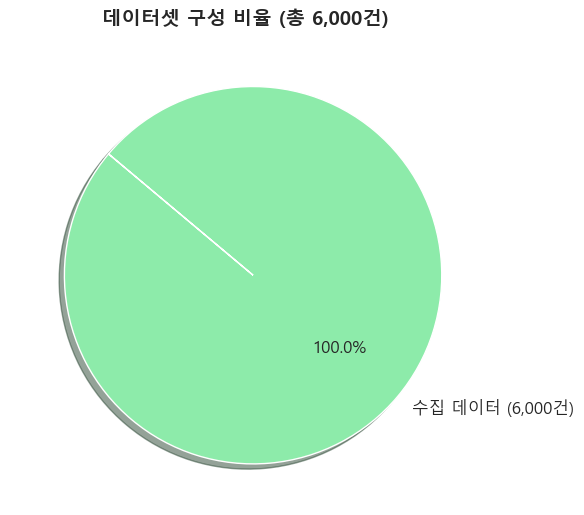

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["axes.unicode_minus"] = False
if platform.system() == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc("font", family=font_name)
# 데이터 정의
labels = ["수집 데이터 (6,000건)"]
sizes = [100]
colors = ["#8DEBAA"]  # 연두색
explode = (0.05,)  # 살짝 강조 효과

# 차트 그리기
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct="%1.1f%%",
    startangle=140,
    shadow=True,
    textprops={"fontsize": 12},
)

# 제목
plt.title(
    "데이터셋 구성 비율 (총 6,000건)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# 최종 피싱데이터 분석

'd:\workspace\woogawooga_project\dataset\phishing_6000_final.csv' 에서 데이터를 불러옵니다...
데이터 불러오기 완료.
file_id를 기준으로 텍스트를 병합하고 글자 수를 계산합니다...
계산 완료.

--- file_id 당 글자 수 통계 ---
count     6000.000000
mean       863.072500
std       2012.456181
min         14.000000
25%        124.000000
50%        203.500000
75%        664.250000
max      24123.000000
Name: char_count, dtype: float64
통계 정보가 'd:\workspace\woogawooga_project\dataset_create\Woojae\..\..\datas/analysisData\phishing_char_count_stats.txt'에 저장되었습니다.
---------------------------------

글자 수 분포 그래프를 생성합니다...
그래프가 'd:\workspace\woogawooga_project\dataset_create\Woojae\..\..\datas/analysisData\phishing_char_count_distribution.png'에 저장되었습니다.

분석이 완료되었습니다.


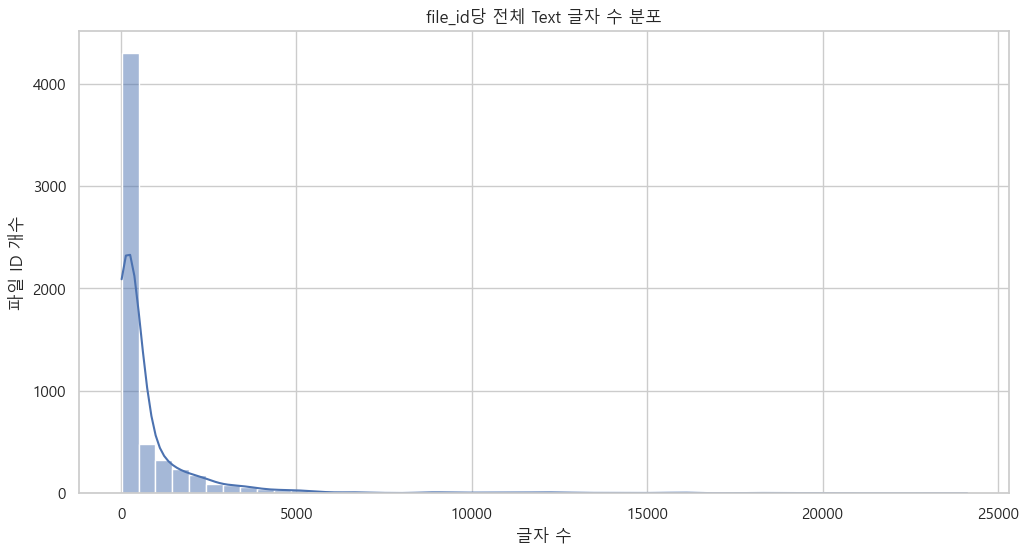

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import platform
from matplotlib import font_manager, rc

plt.rcParams["axes.unicode_minus"] = False
if platform.system() == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc("font", family=font_name)
else:
    rc("font", family="AppleGothic")

sns.set(style="whitegrid")

plt.rcParams["axes.unicode_minus"] = False
if platform.system() == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc("font", family=font_name)


def analyze_phishing_text_length():
    """
    phishing_6000_final.csv 파일을 읽어, file_id별로 text를 합친 후
    글자 수 분포 통계와 그래프를 생성합니다.
    """
    # --- 설정 ---
    # 이 스크립트 파일의 위치를 기준으로 상대 경로를 설정합니다.
    # 스크립트가 'dataset_create/Woojae'에 있으므로, 상위 폴더로 두 번 이동하여 루트에 접근합니다.
    try:
        script_dir = os.path.dirname(__file__)
    except NameError:
        # 대화형 환경(예: Jupyter)에서 실행될 경우를 대비
        script_dir = os.getcwd()

    base_dir = os.path.join(script_dir, "..", "..")
    input_file = os.path.join(base_dir, "dataset", "normal_6000_final.csv")
    output_dir = os.path.join(base_dir, "datas/analysisData")

    # 분석 결과 저장 폴더 생성
    os.makedirs(output_dir, exist_ok=True)

    # 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
    try:
        if os.name == "nt":  # Windows
            plt.rcParams["font.family"] = "Malgun Gothic"
        elif os.name == "posix":  # Mac/Linux
            plt.rcParams["font.family"] = "AppleGothic"
    except Exception as e:
        print(f"폰트 설정 중 오류 발생: {e}. 그래프의 한글이 깨질 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False

    # --- 데이터 불러오기 ---
    print(f"'{os.path.abspath(input_file)}' 에서 데이터를 불러옵니다...")
    try:
        df = pd.read_csv(input_file)
        print("데이터 불러오기 완료.")
    except FileNotFoundError:
        print(
            f"오류: 파일을 찾을 수 없습니다. '{os.path.abspath(input_file)}' 경로를 확인하세요."
        )
        return

    # --- 데이터 분석 ---
    print("file_id를 기준으로 텍스트를 병합하고 글자 수를 계산합니다...")
    # NaN 값을 빈 문자열로 처리하여 오류 방지
    df["text"] = df["text"].fillna("")
    # 그룹화 및 텍스트 병합
    grouped_df = (
        df.groupby("file_id")["text"].apply(lambda x: " ".join(x)).reset_index()
    )

    # 합쳐진 text의 글자 수 계산
    grouped_df["char_count"] = grouped_df["text"].str.len()
    print("계산 완료.")

    # --- 통계 출력 ---
    print("\n--- file_id 당 글자 수 통계 ---")
    stats = grouped_df["char_count"].describe()
    print(stats)
    # 통계 결과를 텍스트 파일로 저장
    stats_path = os.path.join(output_dir, "phishing_char_count_stats.txt")
    with open(stats_path, "w", encoding="utf-8") as f:
        f.write("file_id당 글자 수 통계\n")
        f.write(str(stats))
    print(f"통계 정보가 '{stats_path}'에 저장되었습니다.")
    print("---------------------------------")

    # --- 시각화 ---
    print("\n글자 수 분포 그래프를 생성합니다...")
    plt.figure(figsize=(12, 6))
    sns.histplot(data=grouped_df, x="char_count", kde=True, bins=50)
    plt.title("file_id당 전체 Text 글자 수 분포")
    plt.xlabel("글자 수")
    plt.ylabel("파일 ID 개수")
    plt.grid(True)

    # 그래프를 이미지 파일로 저장
    output_image_path = os.path.join(output_dir, "phishing_char_count_distribution.png")
    plt.savefig(output_image_path)
    print(f"그래프가 '{output_image_path}'에 저장되었습니다.")

    # 화면에 그래프 표시 (스크립트 실행 시 주석 처리 가능)
    # plt.show()

    print("\n분석이 완료되었습니다.")


if __name__ == "__main__":
    analyze_phishing_text_length()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# 파일 경로 (원하는 경로로 수정 가능)
# file_path = "../../dataset/phishing_6000_final.csv"
file_path = r"D:\workspace\woogawooga_project\dataset\normal_6000_final.csv"
output_dir = r"D:\workspace\woogawooga_project\datas"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ 파일이 존재하지 않습니다: {file_path}")
os.makedirs(output_dir, exist_ok=True)

# 데이터 불러오기
df = pd.read_csv(file_path)

# file_name 기준 텍스트 합치기
grouped = (
    df.groupby("file_id")["text"].apply(lambda x: " ".join(map(str, x))).reset_index()
)
grouped["char_count"] = grouped["text"].apply(len)

# 통계 요약 저장
stats_summary = grouped["char_count"].describe()
with open(
    os.path.join(output_dir, "char_count_summary.txt"), "w", encoding="utf-8"
) as f:
    f.write("글자 수 통계 요약:\n")
    f.write(str(stats_summary))

# 기본 히스토그램
plt.figure(figsize=(10, 6))
sns.histplot(grouped["char_count"], bins=30, kde=True)
plt.title("글자 수 분포 (file_name 기준)")
plt.xlabel("글자 수")
plt.ylabel("파일 개수")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "char_count_histogram.png"))
plt.close()

# 구간별 히스토그램 (0-500, 501-1000, 1000이상)
plt.figure(figsize=(12, 5))

# 구간 분류
def categorize_char_count(count):
    if count <= 500:
        return "0-500"
    elif count <= 1000:
        return "501-1000"
    else:
        return "1000이상"

grouped["char_range"] = grouped["char_count"].apply(categorize_char_count)

# 구간별 히스토그램
plt.subplot(1, 2, 1)
bins = [0, 500, 1000, grouped["char_count"].max() + 100]
n, bins_edges, patches = plt.hist(grouped["char_count"], bins=bins, edgecolor='black', alpha=0.7)

# 각 구간에 다른 색상 적용
colors = ['skyblue', 'lightgreen', 'salmon']
for i, patch in enumerate(patches):
    patch.set_facecolor(colors[i])

plt.title("글자 수 분포 (구간별)")
plt.xlabel("글자 수")
plt.ylabel("파일 개수")
plt.xticks([250, 750, (1000 + grouped["char_count"].max()) / 2], 
           ['0-500', '501-1000', '1000이상'])
plt.grid(True, alpha=0.3)

# 구간별 개수 막대그래프
plt.subplot(1, 2, 2)
range_counts = grouped["char_range"].value_counts().reindex(["0-500", "501-1000", "1000이상"])
colors = ['skyblue', 'lightgreen', 'salmon']
bars = plt.bar(range_counts.index, range_counts.values, color=colors, edgecolor='black')
plt.title("구간별 파일 개수")
plt.xlabel("글자 수 구간")
plt.ylabel("파일 개수")

# 막대 위에 개수 표시
for bar, count in zip(bars, range_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "char_count_range_histogram.png"))
plt.close()

# 전체 문자 수 분포 박스플롯
plt.figure(figsize=(10, 6))
sns.boxplot(x=grouped["char_count"])
plt.title("전체 문자 수 분포 (박스플롯)")
plt.xlabel("글자 수")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "char_count_boxplot_detailed.png"))
plt.close()

print("✅ 분석 완료! 결과 파일:")
print(f"- 통계 요약: {output_dir}\\char_count_summary.txt")
print(f"- 기본 히스토그램: {output_dir}\\char_count_histogram.png")
print(f"- 구간별 히스토그램: {output_dir}\\char_count_range_histogram.png")
print(f"- 상세 박스플롯: {output_dir}\\char_count_boxplot_detailed.png")

# 구간별 통계 출력
print("\n📊 구간별 통계:")
for range_name in ["0-500", "501-1000", "1000이상"]:
    count = range_counts.get(range_name, 0)
    percentage = (count / len(grouped)) * 100
    print(f"{range_name}: {count}개 ({percentage:.1f}%)")

✅ 분석 완료! 결과 파일:
- 통계 요약: D:\workspace\woogawooga_project\datas\char_count_summary.txt
- 기본 히스토그램: D:\workspace\woogawooga_project\datas\char_count_histogram.png
- 구간별 히스토그램: D:\workspace\woogawooga_project\datas\char_count_range_histogram.png
- 상세 박스플롯: D:\workspace\woogawooga_project\datas\char_count_boxplot_detailed.png

📊 구간별 통계:
0-500: 4302개 (71.7%)
501-1000: 495개 (8.2%)
1000이상: 1203개 (20.1%)
